# Route a support message

**Recipe template** · Level 1 (Beginner) · Decision type: `Choice`

Route a short support message to a queue, or to a person when no queue clearly fits.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)

## What you will build

A small router for support messages. Jev reads one message and picks exactly one of four options: `billing`, `bug`, `account`, or `none`. Python then decides what that choice is allowed to do: send the ticket to a queue, or hand it to a person. By the end you will have seen the typed answer itself, the rule that acts on it, and an evaluation that selects its one setting on `validation` and reports on `test`.

This notebook is also the template every recipe in the cookbook is copied from, so it is deliberately tiny: 22 made-up messages, one question, one rule. Each section below is a section your recipe has, in the same order.

## Setup and run mode

The notebook runs from its own folder and needs only the standard library and `jev_cookbook`. `get_backend(fixtures=...)` replays stored answers offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls and changes nothing else. The header states which mode ran, and every number below carries that mode with it.

In [1]:
%matplotlib inline

from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_selective,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# A synthetic header states no sample size; a recorded or live one must.
header = run_header(
    "template",
    "Route a support message",
    backend=backend,
    n_examples=None if offline else len(examples),
)

Recipe template: Route a support message
Mode: offline replay of synthetic fixtures
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a ticket reference, a subject and a message. `build_state` passes on the subject and the message only. The reference stays in Python and is attached to the outcome at the end, so an identifier never passes through the model and every result traces back to its ticket.

In [2]:
import json

demo = {e.id: e for e in examples}
ticket = demo["d01"]
print("Python has:")
print(json.dumps(ticket.fields, indent=2))
state = helpers.build_state(ticket.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "ticket": "T-3001",
  "subject": "Wrong amount",
  "message": "My invoice shows the wrong amount for March."
}
Jev sees:
{
  "subject": "Wrong amount",
  "message": "My invoice shows the wrong amount for March."
}


## The questions

There is one question, and it asks one thing: which kind of request is this? A `Choice` fits because the kinds are exclusive and Jev should commit to one. Python builds the option list from the queues it is willing to use, so the options and the queues cannot drift apart. Each option has a short description, because a bare label leaves room for interpretation. The fourth option, `none`, is there on purpose: without it, a message about banana bread would have to be forced into one of the other three.

In [3]:
questions = helpers.build_questions()
route = questions["route"]
print(route.instructions)
for name, description in route.criteria.items():
    print(f"  {name:8s} {description}")

Which kind of support request is this message?
  billing  charges, invoices, refunds, payment methods and renewals
  bug      the product misbehaving: errors, crashes, pages that do not load
  account  signing in, passwords, profile details and who can use the account
  none     anything else, or a message that fits none of the other options


## One answer up close

Before any aggregate, look at one typed answer. A `Choice` answer holds the chosen option, a probability for every option, and a `confidence` derived from that whole distribution. Confidence is not the top probability: it is 0 for an even spread and 1 for a single sure option. The provenance line says where the answer came from.

In [4]:
result = backend.decide(state, questions)
answer = result["route"]
text = show_answer(answer)

Choice: billing (confidence 0.73)
  billing  0.80  ################
  none     0.08  ##
  bug      0.07  #
  account  0.05  #
Provenance: synthetic


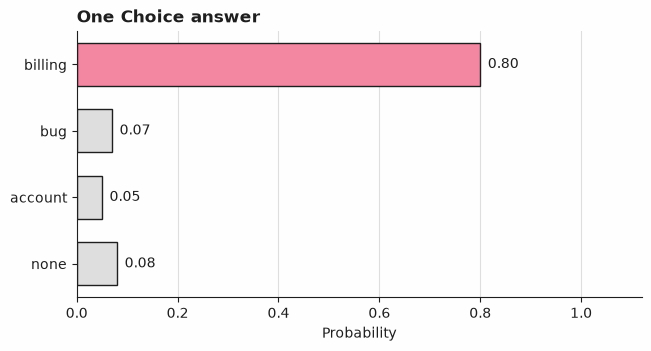

In [5]:
plot_answer_probabilities(answer, title="One Choice answer")

## Python's part

Jev supplies the judgment; the rule that acts on it is code. `route` sends a ticket to a queue only when the answer is one of the queues Python knows and its confidence reaches a threshold. The `none` option, any option that is not a queue, and any answer below the threshold all go to an explicit `human_review` outcome. Nothing the model says can create a new queue or skip review, because the rule lives in `helpers.py` and `tests/test_helpers.py` checks it. The cutoff of 0.5 below is only a starting value: the evaluation chooses the one to keep.

In [6]:
for example_id in ("d01", "d02"):
    example = demo[example_id]
    answer = backend.decide(helpers.build_state(example.fields), questions)["route"]
    routing = helpers.route(example.fields["ticket"], answer, min_confidence=0.5)
    print(
        f"{routing.ticket}: {answer.choice} at confidence {answer.confidence:.2f} "
        f"-> {routing.outcome} ({routing.reason})"
    )

T-3001: billing at confidence 0.73 -> billing-team (confident match)
T-3002: account at confidence 0.36 -> human_review (confidence below the threshold)


## Evaluation

The threshold is the only setting, so it is chosen on `validation` and then frozen. `test` is used once, to report. The selector asks for the lowest threshold at which every answered `validation` example is correct, which keeps as many tickets automatic as that allows. In an offline run every number here is a check that the pipeline works, and it says so.

In [7]:
def decide_split(split):
    chosen = select_split(examples, split)
    answers = [backend.decide(helpers.build_state(e.fields), questions)["route"] for e in chosen]
    return chosen, answers, [labels[e.id] for e in chosen]


val_examples, val_answers, val_gold = decide_split("validation")
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
threshold = select_confidence_threshold(val_correct, val_answers, target_accuracy=1.0)
print(f"validation, {len(val_examples)} examples{check}")
print(f"accuracy {accuracy(val_gold, val_answers):.2f}; chosen threshold {threshold:.2f}")

validation, 10 examples (a pipeline check, not a Jev result)
accuracy 0.80; chosen threshold 0.67


In [8]:
test_examples, test_answers, test_gold = decide_split("test")
print(f"test, {len(test_examples)} examples, threshold {threshold:.2f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.2f}")
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
selective = evaluate_selective(test_correct, test_answers, threshold)
print(
    f"answered {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.2f}); accuracy when answered {selective.accuracy:.2f}"
)

test, 10 examples, threshold 0.67 frozen (a pipeline check, not a Jev result)
accuracy of the choice: 0.80
answered 8 of 10 (coverage 0.80); accuracy when answered 0.88


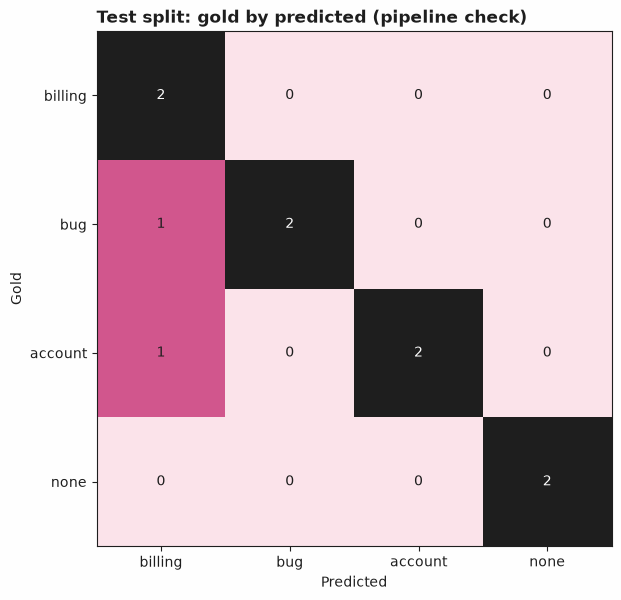

In [9]:
matrix = confusion_matrix(test_gold, test_answers, labels=[*helpers.QUEUES, helpers.NONE])
plot_confusion_matrix(matrix, title="Test split: gold by predicted (pipeline check)")

In [10]:
print("Test examples the choice got wrong, and what Python did with them:")
for example, answer, gold in zip(test_examples, test_answers, test_gold, strict=True):
    routing = helpers.route(example.fields["ticket"], answer, threshold)
    if answer.choice != gold:
        print(
            f"  {example.id}: gold {gold}, answered {answer.choice} "
            f"(confidence {answer.confidence:.2f}) -> {routing.outcome}"
        )

Test examples the choice got wrong, and what Python did with them:
  t08-lookalike: gold bug, answered billing (confidence 0.36) -> human_review
  t09-mixed: gold account, answered billing (confidence 0.71) -> billing-team


The cell above is why the rule is not enough on its own: a wrong answer with a high confidence passes the threshold, and a look-alike message (an invoice page that will not load) can sit near the line between two options. The fixtures include such cases on purpose, and a recipe's evaluation should find them rather than average them away.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 22 invented messages. Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose, so the accuracy above describes the fixtures and not a model.

In [11]:
if offline:
    print("Provenance: synthetic. Not measured live.")
else:
    print(f"Provenance: {backend.mode}, model {backend.model}")

Provenance: synthetic. Not measured live.


## Next steps

- Change one option description in `helpers.py`, rerun `python build_fixtures.py`, and read the validator's report: the replay keys change with the question.
- Add a message to `build_fixtures.py` that you think the router will find hard, and see where the rule sends it.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/), [`02-refund-intent-detection`](../02-refund-intent-detection/) and [`04-support-ticket-routing`](../04-support-ticket-routing/), which grow this single question into a fuller routing decision.